In [1]:
import sys
import os
curr_dir=os.getcwd()
ROOT_DIR = os.path.abspath(os.path.join(curr_dir, os.pardir, os.pardir))
print(f"Root directory: {ROOT_DIR}")
if ROOT_DIR not in sys.path:
    sys.path.append(ROOT_DIR)

from liset_data_reader.liset_paper import liset_paper
import numpy as np
import matplotlib.pyplot as plt
from liset_data_reader.signal_aid import bandpass_filter
import matplotlib.pyplot as plt
import seaborn as sns
from copy import deepcopy
plt.rcParams['svg.fonttype'] = 'none'

Root directory: c:\Users\NCN\Documents\PedroFelix\LAVA_SNN_ripples


In [3]:
parent=r"C:\PedroFelix\Download_from_paper"
# parent=r"E:\NCN\neurospark_mat\Download_from_paper"
datasets=os.listdir(parent)
dataset=2
dataset_path=os.path.join(parent,datasets[dataset])
print(f"Processing dataset: {datasets[dataset]}")
dataset=datasets[dataset]

Processing dataset: Som2_2019-07-24_12-01-49


In [4]:
liset=liset_paper(dataset_path, shank=1, downsample=False, start=0, verbose=False)


In [5]:
ch=1
channel_data=liset.data[:,ch]

In [6]:
from process_signal import spikify_signal,reconstruct_signal_from_spikes
filtered_signal=bandpass_filter(channel_data, bandpass=[100,250], fs=liset.fs, order=4)

time_max=20.0
overlap=0.5
adapt_threshold=True
percentile=False
window_size=0.10
sample_ratio=0.25
scaling_factor=1.0
refractory=0
factor=30

spikified, thresholds= spikify_signal(
                        filtered_signal,
                        fs=liset.fs,
                        time_max=time_max,
                        overlap=overlap,
                        adapt_threshold=adapt_threshold,
                        percentile=percentile,
                        window_size=window_size,   
                        sample_ratio=sample_ratio,
                        scaling_factor=scaling_factor,
                        refractory=refractory,
                        factor=factor,
                        initial_value=None,
                        verbose=False,
                        ripples=None,     # kept for compatibility but unused
                    )

In [7]:
print(spikified.shape)

(1036253, 2)


In [8]:
reconstructed_signal = reconstruct_signal_from_spikes(
    spikified, thresholds, adapt_threshold =adapt_threshold,
    fs_spikes=1000,
    time_max=time_max,
    overlap=overlap,
    scaling_factor=1.0, # Not actually used if factor is passed, but kept for signature
    factor=factor,          # Downsampling factor used in spikify
    original_fs=liset.fs, 
    highpass=100)

In [14]:
def plot_offline_detections(liset,channel_data,spikes=None,ch=None, offset=0, filtered=None, extend=0.5, title='Overview', window=None, plot_offline=True,plot_light=True,plot_predicted=True,lims=None,fs=liset.fs):
    """
    Plot data with overlays for:
    - Ground truth ripples (yellow)
    - Model predicted ripples (blue)
    - Light stimulation TTLs (red)

    Parameters
    ----------
    ch : int or list of ints, optional
        Channel(s) to plot. If None, plots the first channel.
    offset : float, optional
        Vertical offset between channels.
    filtered : tuple (low, high), optional
        Bandpass filter range (Hz).
    extend : float, optional
        Extra context (in seconds) around each event.
    title : str, optional
        Title for the plot.
    window : tuple (start, end), optional
        Time window in seconds to plot (e.g., (10, 20)).
    """

    # ---------------------
    # Select channels
    # ---------------------
    if ch is None:
        ch = [0]
    elif isinstance(ch, int):
        ch = [ch]

    n_samples = len(channel_data)
    time = np.arange(n_samples) / fs
    time_spikes = np.arange(len(spikes)) / 1000 if spikes is not None else None # spikes always 1 kHz
    print(f"TIME SPIKES SHAPE: {time_spikes.shape if time_spikes is not None else 'N/A'}")
    # ---------------------
    # Apply time window
    # ---------------------
    if window is not None:
        start_s, end_s = window
        start_idx = int(start_s * fs)
        end_idx = int(end_s * fs)
        
        if spikes is not None:
            start_spikes_idx= int(start_s * 1000)  # assuming spikes are at 1 kHz
            end_spikes_idx= int(end_s * 1000) # assuming spikes are at 1 kHz
            spikes = spikes[start_spikes_idx:end_spikes_idx]
            time_spikes = time_spikes[start_spikes_idx:end_spikes_idx]
            print(f"Spikes shape after windowing: {spikes.shape}")
            
        time = time[start_idx:end_idx]
        print(f"Time spikes shape after windowing: {time_spikes.shape if time_spikes is not None else 'N/A'}")
        data_slice = channel_data[start_idx:end_idx]
    else:
        data_slice = channel_data

    fig, ax = plt.subplots(figsize=(8, 4))
    # plt.title(title)
    # plt.xlabel("Time (s)")
    # plt.ylabel("Amplitude [z-score]")

    # ---------------------
    # Plot data (optionally filtered)
    # ---------------------
    for i, ch_idx in enumerate(ch):
        sig = data_slice if window is None else channel_data[start_idx:end_idx]
        if filtered:
            sig = bandpass_filter(sig, filtered, liset.fs)

        ax.plot(time, sig + i * offset, color="black", lw=1.2, label=f"Ch {ch_idx}" if i == 0 else "")

    min_y, max_y = (ax.get_ylim()) if lims is None else lims
    if abs(min_y)!=abs(max_y):
        print(f"Warning: min_y and max_y are not symmetric: min_y={min_y}, max_y={max_y}")
        min_y, max_y = -max(abs(min_y), abs(max_y)), max(abs(min_y), abs(max_y))
    # Spike masking
    if spikes is not None:
        up_mask = spikes[:, 0] > 0
        down_mask = spikes[:, 1] > 0
        print(f"up_mask shape: {up_mask.shape}, down_mask shape: {down_mask.shape}")
        print(f"Number of UP spikes: {np.sum(up_mask)}, Number of DOWN spikes: {np.sum(down_mask)}")
        up_spike_times = time_spikes[up_mask]
        down_spike_times = time_spikes[down_mask]

    # ---------------------
    # Helper function to plot intervals safely within window
    # ---------------------
    def plot_intervals(intervals, color, label):
        if window is not None:
            mask = (intervals[:, 1] / liset.fs > start_s) & (intervals[:, 0] / liset.fs < end_s)
            intervals = intervals[mask]
            print(f"Plotted {len(intervals)} ground truth ripple intervals.")
            print(f"Ground truth intervals (s): {intervals / fs}")
        for i, r in enumerate(intervals):
            ax.fill_between(r / liset.fs, min_y, max_y, color=color, alpha=0.2, label=label if i == 0 else "")


    # ---------------------
    # Ground truth ripples (yellow)
    # ---------------------
    if hasattr(liset, "ripples_GT") and liset.ripples_GT is not None:
        plot_intervals(liset.ripples_GT, "gold", "Ground truth")




    if spikes is not None:
        spike_height = (max_y - min_y) * 0.12
        ax.vlines(up_spike_times, ymin=max_y - spike_height*2, ymax=max_y - spike_height,
                color='red', linewidth=1, alpha=0.5, label='UP Spikes')
        ax.vlines(down_spike_times, ymin=min_y + spike_height, ymax=min_y + spike_height*2,
                color='blue', linewidth=1, alpha=0.5, label='DN Spikes')
    # ---------------------
    # Beautify
    # ---------------------
    handles, labels = ax.get_legend_handles_labels()
    unique = dict(zip(labels, handles))
    ax.legend(unique.values(), unique.keys(),fontsize=14)
    ax.set_xlim(min(time), max(time))
    ax.set_ylim(min_y, max_y)
    # ax.grid(False, linestyle='--', alpha=0.3)
    ax.grid(False)
    
    # Remove ticks and labels
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel("")
    ax.set_ylabel("")

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)
    
    # Add 100 ms scale bar
    scale_bar_length = 0.1  # 100 ms in seconds
    x_range = max(time) - min(time)
    y_range = max_y - min_y
    
    # Position the bar at the bottom right with some padding
    bar_x = max(time) - x_range * 0.02 - scale_bar_length
    bar_y = min_y + y_range * 0.02

    
    ax.plot([bar_x, bar_x + scale_bar_length], [bar_y, bar_y], color='black', lw=3)
    ax.text(bar_x + scale_bar_length/2, bar_y + y_range * 0.02, '100 ms', ha='center', va='bottom', fontsize=12)

    y_scale_bar_length=1
    ax.plot([bar_x, bar_x], [bar_y, bar_y + y_scale_bar_length], color='black', lw=3)
    ax.text(bar_x- x_range * 0.02, bar_y + y_scale_bar_length/2, '1 z', ha='center', va='bottom', fontsize=12, rotation=90)

    # ax.spines['bottom'].set_linewidth(2)
    # ax.spines['left'].set_linewidth(2)
    # ax.set_axisbelow(True)
    plt.tight_layout()
    plt.show()
    return fig, ax, (min_y, max_y)

TIME SPIKES SHAPE: N/A
Time spikes shape after windowing: N/A
Plotted 1 ground truth ripple intervals.
Ground truth intervals (s): [[413.07103333 413.109     ]]


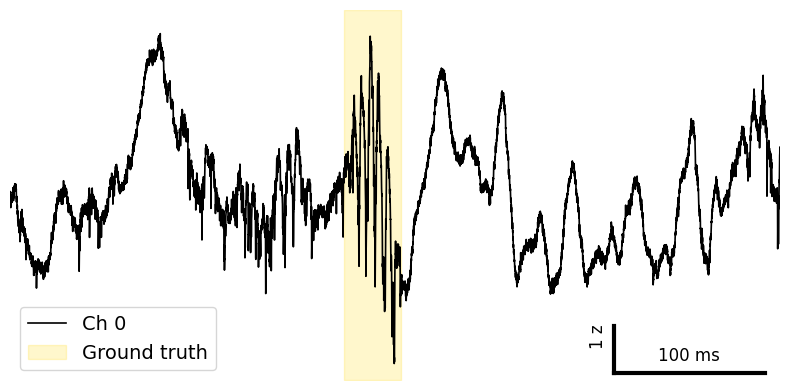

In [15]:
window_start=412.85
window_size=0.510
window=(window_start,window_start+window_size)
fig,ax, lims= plot_offline_detections(liset,channel_data,ch=0,plot_offline=False,plot_light=False,plot_predicted=False, window=window)
# fig.savefig(f"pngs/methods_figure_raw_{window[0]}_{window[1]}_ch{ch}_dataset_{dataset}.svg", dpi=500)

TIME SPIKES SHAPE: (1036253,)
Spikes shape after windowing: (510, 2)
Time spikes shape after windowing: (510,)
up_mask shape: (510,), down_mask shape: (510,)
Number of UP spikes: 29, Number of DOWN spikes: 28
Plotted 1 ground truth ripple intervals.
Ground truth intervals (s): [[413.07103333 413.109     ]]


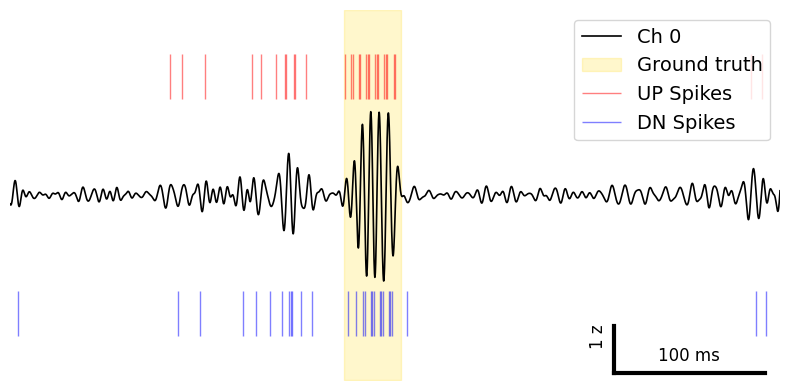

In [16]:
fig,ax, lims_filtered= plot_offline_detections(liset,filtered_signal,spikes=spikified,ch=0,plot_offline=False,plot_light=False,plot_predicted=False, window=window,lims=lims)
# fig.savefig(f"pngs/methods_figure_filtered_{window[0]}_{window[1]}_ch{ch}_dataset_{dataset}.svg", dpi=500)


TIME SPIKES SHAPE: (1036253,)
Spikes shape after windowing: (510, 2)
Time spikes shape after windowing: (510,)
up_mask shape: (510,), down_mask shape: (510,)
Number of UP spikes: 29, Number of DOWN spikes: 28
Plotted 1 ground truth ripple intervals.
Ground truth intervals (s): [[12392.131 12393.27 ]]


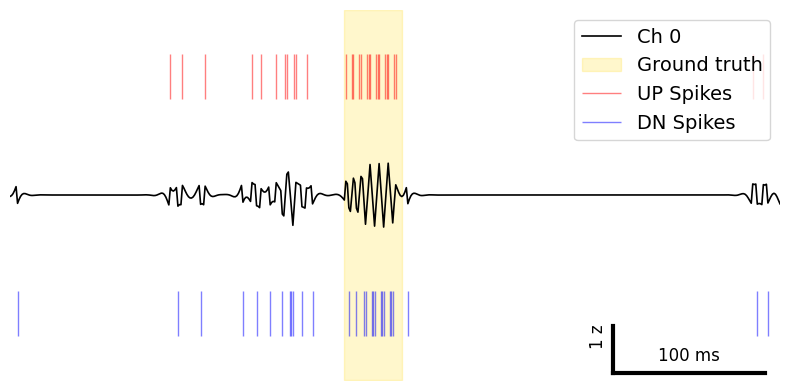

In [18]:
fig,ax,lims_reconstruction= plot_offline_detections(liset,reconstructed_signal,fs=1000,spikes=spikified,ch=0,plot_offline=False,plot_light=False,plot_predicted=False, window=window,lims=lims)
fig.savefig(f"pngs/methods_figure_reconstruction_{window[0]}_{window[1]}_ch{ch}_dataset_{dataset}.svg", dpi=500)


TIME SPIKES SHAPE: (1036253,)
Spikes shape after windowing: (120, 2)
Time spikes shape after windowing: (120,)
up_mask shape: (120,), down_mask shape: (120,)
Number of UP spikes: 23, Number of DOWN spikes: 24
Plotted 1 ground truth ripple intervals.
Ground truth intervals (s): [[413.07103333 413.109     ]]


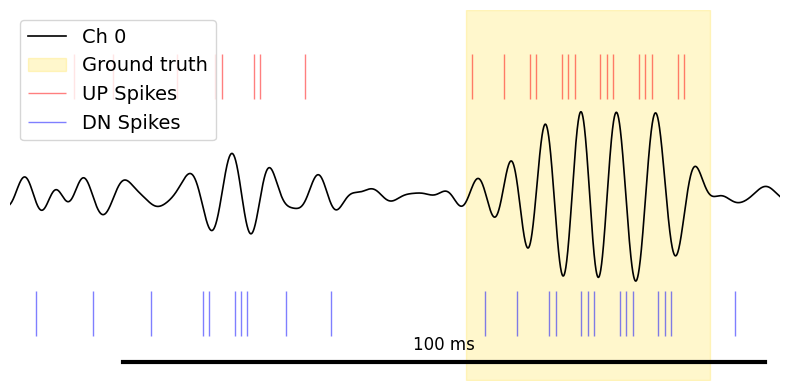

In [204]:
window_ripple=(413,413.12)
fig,ax, lims_filtered= plot_offline_detections(liset,filtered_signal,spikes=spikified,ch=0,plot_offline=False,plot_light=False,plot_predicted=False, window=window_ripple,lims=lims)
fig.savefig(f"pngs/methods_figure_raw_{window_ripple[0]}_{window_ripple[1]}_ch{ch}_dataset_{dataset}.svg", dpi=500)

# Get Windows Training...


In [157]:
window_s=window
window_size=180
overlap=60
RIPPLE_DETECTION_OFFSET = [18, 45, 31, 20] # it's calculated as 4.5 periods of the ripple wavelet - for 100 Hz and 250 Hz as the limit frequencies
MEAN_DETECTION_OFFSET=31
MAX_DETECTION_OFFSET=RIPPLE_DETECTION_OFFSET[1]

def get_window_lims_gts(liset,window,window_size,overlap,mean_detection_offset, max_detection_offset):

    if window is not None:
        start_s, end_s = window
        start_ms=int(start_s*1000)
        end_ms=int(end_s*1000)

    ripples=liset.ripples_GT
    ripples_ms=ripples/liset.fs*1000
    ripples_in_window=[]
    for ripple in ripples_ms:
        if ripple[1]>=start_ms and ripple[0]<=end_ms:
            ripples_in_window.append(ripple)
    ripples_in_window=np.array(ripples_in_window)

    WINDOW_SHIFT=window_size-overlap
    windows_to_plot=[]
    current_idx=0
    gt_annotations=[]
    for i in range(start_ms, end_ms-WINDOW_SHIFT, WINDOW_SHIFT):
        left, right = i, i+window_size
        windows_to_plot.append((left,right))
        cur_ripple=ripples_in_window[current_idx]
        
        while cur_ripple[1]<left and current_idx<len(ripples_in_window)-1:
            current_idx+=1
            cur_ripple=ripples_in_window[current_idx]

        if cur_ripple[0]<=right and cur_ripple[1]>=left:
            if cur_ripple[0]+max_detection_offset<=right:
                gt=int(cur_ripple[0] + mean_detection_offset-left)
                print(f"GT annotation for window ({left}, {right}): {gt} ms (ripple at {cur_ripple[0]} ms)")
            else:
                print(f"Ripple at {cur_ripple[0]-left} ms is too close to the right edge of the window ({right} ms) for a valid GT annotation.")
                gt=False

            if cur_ripple[0]<left:
                print(f"Ripple at {cur_ripple[0]-left} ms is too close to the left edge of the window ({left} ms) for a valid GT annotation.")
                gt=False

        else:
            gt=-1
        gt_annotations.append(gt)

    print(gt_annotations)
    return windows_to_plot, gt_annotations

windows_to_plot,gt_annotations=get_window_lims_gts(liset,window,window_size,overlap,MEAN_DETECTION_OFFSET, MAX_DETECTION_OFFSET)

GT annotation for window (412970, 413150): 132 ms (ripple at 413071.0333333333 ms)
GT annotation for window (413090, 413270): 12 ms (ripple at 413071.0333333333 ms)
Ripple at -18.966666666674428 ms is too close to the left edge of the window (413090 ms) for a valid GT annotation.
[-1, 132, False, -1]


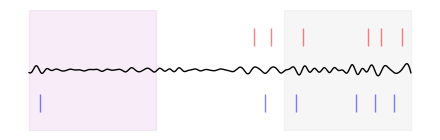

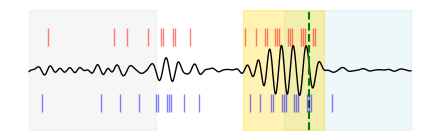

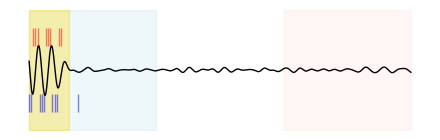

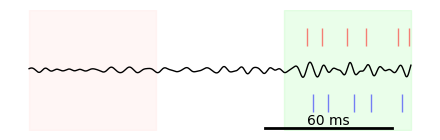

In [206]:
def plot_windows_sequence(liset, channel_data, windows, gt_annotations, spikes=None, filtered_band=None,lims=None):
    figures = []
    
    # Calculate global Y limits
    global_ymin = np.inf
    global_ymax = -np.inf
    
    sr = liset.fs
    
    processed_signals = []
    
    for (start_ms, end_ms) in windows:
        s_idx = int(start_ms * sr / 1000)
        e_idx = int(end_ms * sr / 1000)
        # Ensure bounds
        s_idx = max(0, s_idx)
        e_idx = min(len(channel_data), e_idx)
        
        sig_segment = channel_data[s_idx:e_idx]
        if filtered_band:
            sig_segment = bandpass_filter(sig_segment, filtered_band, sr)
        
        processed_signals.append(sig_segment)
        
        if len(sig_segment) > 0:
            if lims is None:
                ymin, ymax = sig_segment.min(), sig_segment.max()
                if ymin < global_ymin: global_ymin = ymin
                if ymax > global_ymax: global_ymax = ymax
            else:
                ymin, ymax = lims
                if ymin < global_ymin: global_ymin = ymin
                if ymax > global_ymax: global_ymax = ymax
    # Add some padding to Y limits
    if global_ymin != np.inf:
        y_range = global_ymax - global_ymin
        global_ymin -= y_range * 0.05
        global_ymax += y_range * 0.05
    else:
        global_ymin, global_ymax = -1, 1

    for i, ((start_ms, end_ms), gt_target, sig_segment) in enumerate(zip(windows, gt_annotations, processed_signals)):
        fig, ax = plt.subplots(figsize=(4.5, 1.5))
        figures.append(fig)
        
        # Time array for signal
        t_segment = np.linspace(0, end_ms - start_ms, len(sig_segment))
    
        # Plot Signal
        ax.plot(t_segment, sig_segment, color='k', lw=1)
        
        # Set shared Y limits
        ax.set_ylim(global_ymin, global_ymax)
        ymin, ymax = global_ymin, global_ymax # Use these for overlays

        # Plot GT Target Line
        if gt_target != -1 and gt_target is not False:
             # gt_target is latency from window start
            ax.vlines(gt_target, ymin, ymax, color='green', linestyle='--', lw=1.5)

        # Style
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['bottom'].set_visible(False)
        ax.spines['left'].set_visible(False)
        ax.set_yticks([])
        ax.set_xticks([])
        
        # Backgrounds
        if i == 0:
            ax.fill_between([0, 60], ymin, ymax, color='plum', alpha=0.2)
            ax.fill_between([120, 180], ymin, ymax, color='lightgray', alpha=0.2)
        elif i == 1:
            ax.fill_between([0, 60], ymin, ymax, color='lightgray', alpha=0.2)
            ax.fill_between([120, 180], ymin, ymax, color='lightblue', alpha=0.2)
        elif i == 2:
            ax.fill_between([0, 60], ymin, ymax, color='lightblue', alpha=0.2)
            ax.fill_between([120, 180], ymin, ymax, color='mistyrose', alpha=0.3)
        elif i == 3:
            ax.fill_between([0, 60], ymin, ymax, color='mistyrose', alpha=0.3)
            ax.fill_between([120, 180], ymin, ymax, color='palegreen', alpha=0.2)           
        
        # Spikes
        if spikes is not None:
            sp_start_idx = int(start_ms)
            sp_end_idx = int(end_ms)
            
            if sp_start_idx < len(spikes):
                 # Ensure we don't go out of bounds
                 sp_end_idx = min(len(spikes), sp_end_idx)
                 sp_seg = spikes[sp_start_idx:sp_end_idx]
                 
                 # Time for spikes relative to window start (0 to 180ms)
                 # Assuming 1 index = 1 ms as before
                 t_spikes = np.arange(len(sp_seg)) 
                 
                 up_mask = sp_seg[:, 0] > 0
                 down_mask = sp_seg[:, 1] > 0

                 spike_h = (ymax - ymin) * 0.15
                 if np.any(up_mask):
                     ax.vlines(t_spikes[up_mask], ymax - 2*spike_h, ymax - spike_h, color='red', alpha=0.5,linewidth=1.0)
                 if np.any(down_mask):
                     ax.vlines(t_spikes[down_mask], ymin + spike_h, ymin + 2*spike_h, color='blue', alpha=0.5,linewidth=1.0)

        # Plot GT Intervals (Yellow)
        if hasattr(liset, 'ripples_GT') and liset.ripples_GT is not None:
            # Convert GT to ms
            gt_ms = liset.ripples_GT / sr * 1000
            for r_start, r_end in gt_ms:
                # Check overlap
                if r_end > start_ms and r_start < end_ms:
                    # Relative coordinates
                    rel_s = max(0, r_start - start_ms)
                    rel_e = min(end_ms - start_ms, r_end - start_ms)
                    ax.fill_between([rel_s, rel_e], ymin, ymax, color='gold', alpha=0.3)

        # Scale bar on last
        if i == len(windows) - 1:
            win_len = end_ms - start_ms
            bar_len = 60
            bar_x = win_len - bar_len - (win_len*0.05)
            # bar_y = ymin
            # Re-calculate bar_y based on new fixed limits if needed, but ymin is fixed now.
            # Just push it a bit up if needed or keep at ymin.
            # Since ymin is the graph minimum, the bar will sit at the bottom.
            bar_y = ymin + (ymax-ymin) * 0.02
            
            ax.plot([bar_x, bar_x+bar_len], [bar_y, bar_y], color='k', lw=2)
            ax.text(bar_x + bar_len/2, bar_y, "60 ms", ha='center', va='bottom', fontsize=10)

        plt.tight_layout()
        plt.show() # Show each figure immediately
        
    return figures

figs = plot_windows_sequence(liset, filtered_signal, windows_to_plot, gt_annotations, spikes=spikified,lims=lims)
for i,figure in enumerate(figs):
    figure.savefig(f"pngs/methods_figure_window_{window[0]}_{window[1]}_ch{ch}_dataset_{dataset}_{i}.svg", dpi=500)


In [ ]:
# PLOT ONLY THE SECOND WINDOW